# Marketing Campaign Customer Segmentation & Analytics

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')


In [37]:
df = pd.read_csv('../data/marketing_campaign.csv', sep='\t')

df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


In [38]:
df.shape

(2240, 29)

In [39]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='str')

In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   str    
 3   Marital_Status       2240 non-null   str    
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   str    
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   int64  
 16 

In [41]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [42]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [43]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

In [44]:
df.duplicated().sum()

np.int64(0)

In [45]:
#df = df.drop_duplicates()

In [46]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52237.975446,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25037.955891,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35538.750000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68289.750000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [47]:
df['Age'] = 2025 - df['Year_Birth']

In [48]:
df['Total_Spending'] = (
    df['MntWines']
    + df['MntFruits']
    + df['MntMeatProducts']
    + df['MntFishProducts']
    + df['MntSweetProducts']
    + df['MntGoldProds']
)

In [49]:
df[['Age', 'Total_Spending']].head()

,Age,Total_Spending
0,68,1617
1,71,27
2,60,776
3,41,53
4,44,422


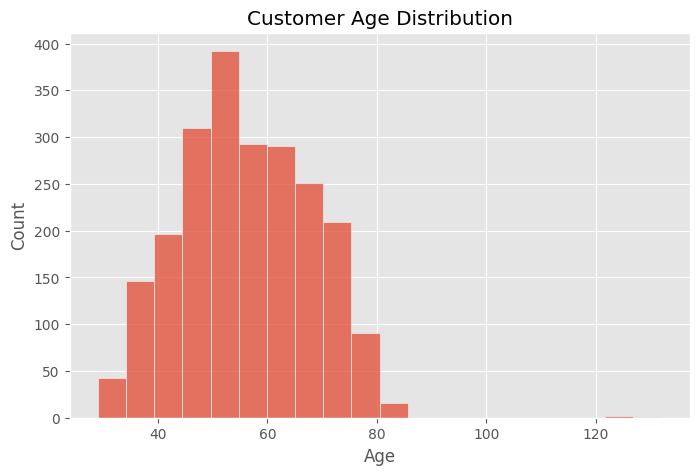

In [50]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20)

plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.show()

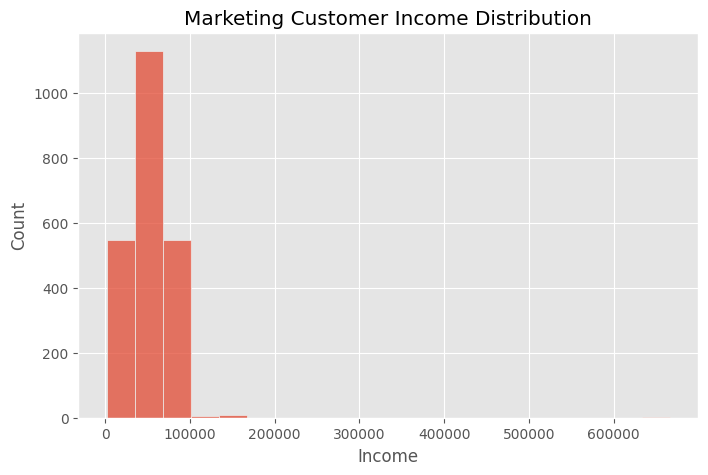

In [51]:
plt.figure(figsize=(8,5))

sns.histplot(df['Income'], bins=20)

plt.title('Marketing Customer Income Distribution')
plt.xlabel('Income')
plt.ylabel('Count')

plt.show()

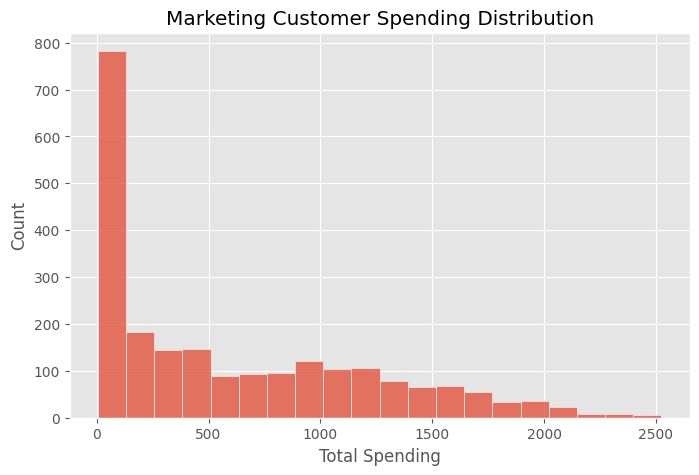

In [52]:
plt.figure(figsize=(8,5))

sns.histplot(df['Total_Spending'], bins=20)

plt.title('Marketing Customer Spending Distribution')
plt.xlabel('Total Spending')
plt.ylabel('Count')

plt.show()

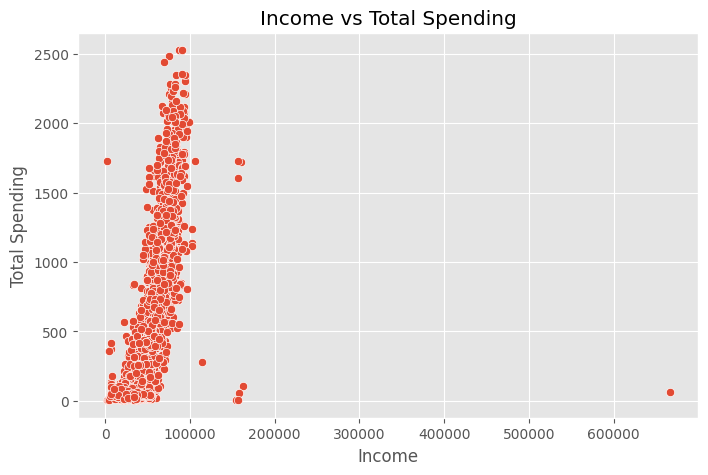

In [53]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Income'],
    y=df['Total_Spending']
)

plt.title('Income vs Total Spending')
plt.xlabel('Income')
plt.ylabel('Total Spending')

plt.show()

In [54]:
X = df[['Income', 'Total_Spending', 'Age']]

In [55]:
X.head()

,Income,Total_Spending,Age
0,58138.0,1617,68
1,46344.0,27,71
2,71613.0,776,60
3,26646.0,53,41
4,58293.0,422,44


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [57]:
X_scaled[:5]

array([[ 0.23569584,  1.67941681,  0.98534473],
       [-0.23545419, -0.96127545,  1.23573295],
       [ 0.77399892,  0.28267329,  0.3176428 ],
       [-1.02235542, -0.91809432, -1.26814929],
       [ 0.24188782, -0.30525442, -1.01776106]])

In [58]:
from sklearn.cluster import KMeans

In [59]:
inertia = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

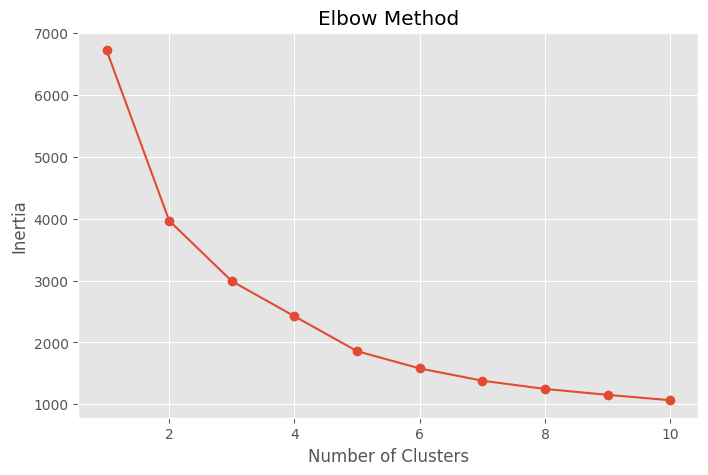

In [60]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')

plt.show()

In [61]:
kmeans = KMeans(n_clusters=5, random_state=42)

df['Cluster'] = kmeans.fit_predict(X_scaled)

In [62]:
df[['Income', 'Total_Spending', 'Age', 'Cluster']].head()

,Income,Total_Spending,Age,Cluster
0,58138.0,1617,68,2
1,46344.0,27,71,1
2,71613.0,776,60,2
3,26646.0,53,41,0
4,58293.0,422,44,0


In [63]:
df['Cluster'].value_counts()

Cluster
0    829
1    552
3    461
2    397
4      1
Name: count, dtype: int64

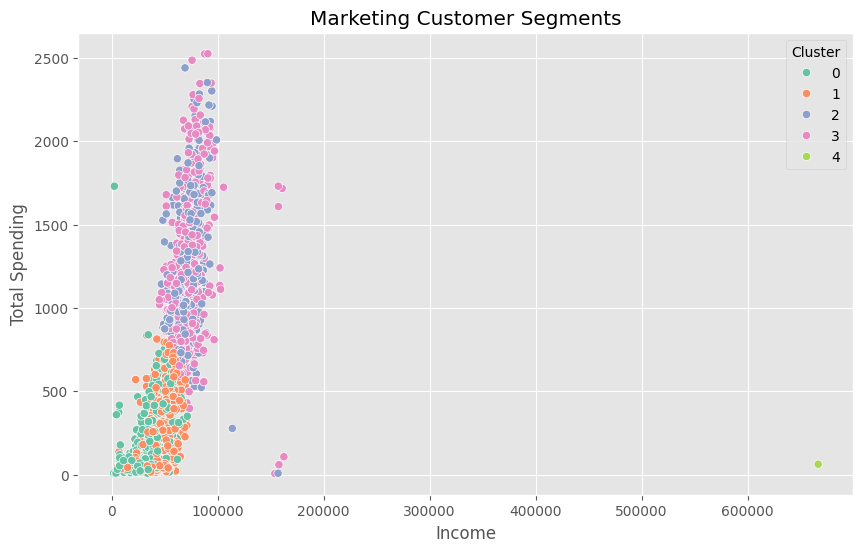

In [64]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Income'],
    y=df['Total_Spending'],
    hue=df['Cluster'],
    palette='Set2'
)

plt.title('Marketing Customer Segments')
plt.xlabel('Income')
plt.ylabel('Total Spending')

plt.savefig('../screenshots/customer_segments.png')

plt.show()

In [65]:
cluster_summary = df.groupby('Cluster')[
    ['Income', 'Total_Spending', 'Age']
].mean()

cluster_summary.round(2)

,Income,Total_Spending,Age
Cluster,,,
0,34369.38,147.90,47.60
1,45644.86,267.84,66.82
2,72611.53,1258.89,68.87
3,73387.08,1272.64,48.02
4,666666.00,62.00,48.00


In [66]:
df['Cluster'].value_counts().sort_index()

Cluster
0    829
1    552
2    397
3    461
4      1
Name: count, dtype: int64

### 💡 Marketing Campaign Insights

### Key Findings

- Customer groups were successfully segmented using K-Means clustering.
- High-income customers generally showed higher spending behavior.
- Some customers had high income but relatively lower spending, indicating potential growth opportunities.
- A few outlier customers were identified with extremely high income values.
- Customer segmentation can help businesses personalize marketing strategies.

### Recommendations

- Target premium customers with loyalty programs and exclusive offers.
- Re-engage medium-spending customers using personalized campaigns.
- Analyze low-spending high-income customers for upselling opportunities.
- Monitor outlier customers separately for strategic business decisions.
- Use customer segmentation to improve marketing efficiency and customer retention.

In [67]:
df.to_csv('../data/marketing_campaign_processed.csv', index=False)